# EDA 1h vs 15m Compare\n\n1시간 데이터와 15분 데이터를 같은 계량기/같은 기간에 비교하는 노트북입니다. 15분 drill-down과 해상도 비교를 위한 템플릿입니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import text

PROJECT_ROOT = Path('/home/playdata2/final_pj/energy-platform')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config.meter_metadata import get_metadata
from scripts.fetch_h1z16_with_weather import build_engine

METER_URN = 'H1.Z16'
START_TS = '2023-07-01 00:00:00'
END_TS = '2023-07-07 23:59:59'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'eda' / 'compare_1h_15m'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metadata = get_metadata(METER_URN)
target_col = metadata['anomaly_target']
engine = build_engine()

## 1. 데이터 로드

In [ ]:
query_tpl = """
SELECT
    ts,
    meter_urn,
    MAX(CASE WHEN measurement = :target_col THEN value END) AS target_value
FROM ems.{table_name}
WHERE meter_urn = :meter_urn
  AND ts BETWEEN :start_ts AND :end_ts
GROUP BY ts, meter_urn
ORDER BY ts
"""

df_1h = pd.read_sql(
    text(query_tpl.format(table_name='cr_measurement_1h')),
    con=engine,
    params={'target_col': target_col, 'meter_urn': METER_URN, 'start_ts': START_TS, 'end_ts': END_TS},
    parse_dates=['ts']
)


df_15m = pd.read_sql(
    text(query_tpl.format(table_name='cr_measurement_15min')),
    con=engine,
    params={'target_col': target_col, 'meter_urn': METER_URN, 'start_ts': START_TS, 'end_ts': END_TS},
    parse_dates=['ts']
)

print(df_1h.shape, df_15m.shape)
display(df_1h.head())
display(df_15m.head())

(168, 3) (672, 3)


,ts,meter_urn,target_value
0,2023-07-01 00:00:00+00:00,H1.Z16,436.173667
1,2023-07-01 01:00:00+00:00,H1.Z16,439.114500
2,2023-07-01 02:00:00+00:00,H1.Z16,435.492833
3,2023-07-01 03:00:00+00:00,H1.Z16,437.430500
4,2023-07-01 04:00:00+00:00,H1.Z16,437.109333


,ts,meter_urn,target_value
0,2023-07-01 00:00:00+00:00,H1.Z16,437.040000
1,2023-07-01 00:15:00+00:00,H1.Z16,437.202000
2,2023-07-01 00:30:00+00:00,H1.Z16,436.363333
3,2023-07-01 00:45:00+00:00,H1.Z16,434.089333
4,2023-07-01 01:00:00+00:00,H1.Z16,440.021333


## 2. 시계열 시각화

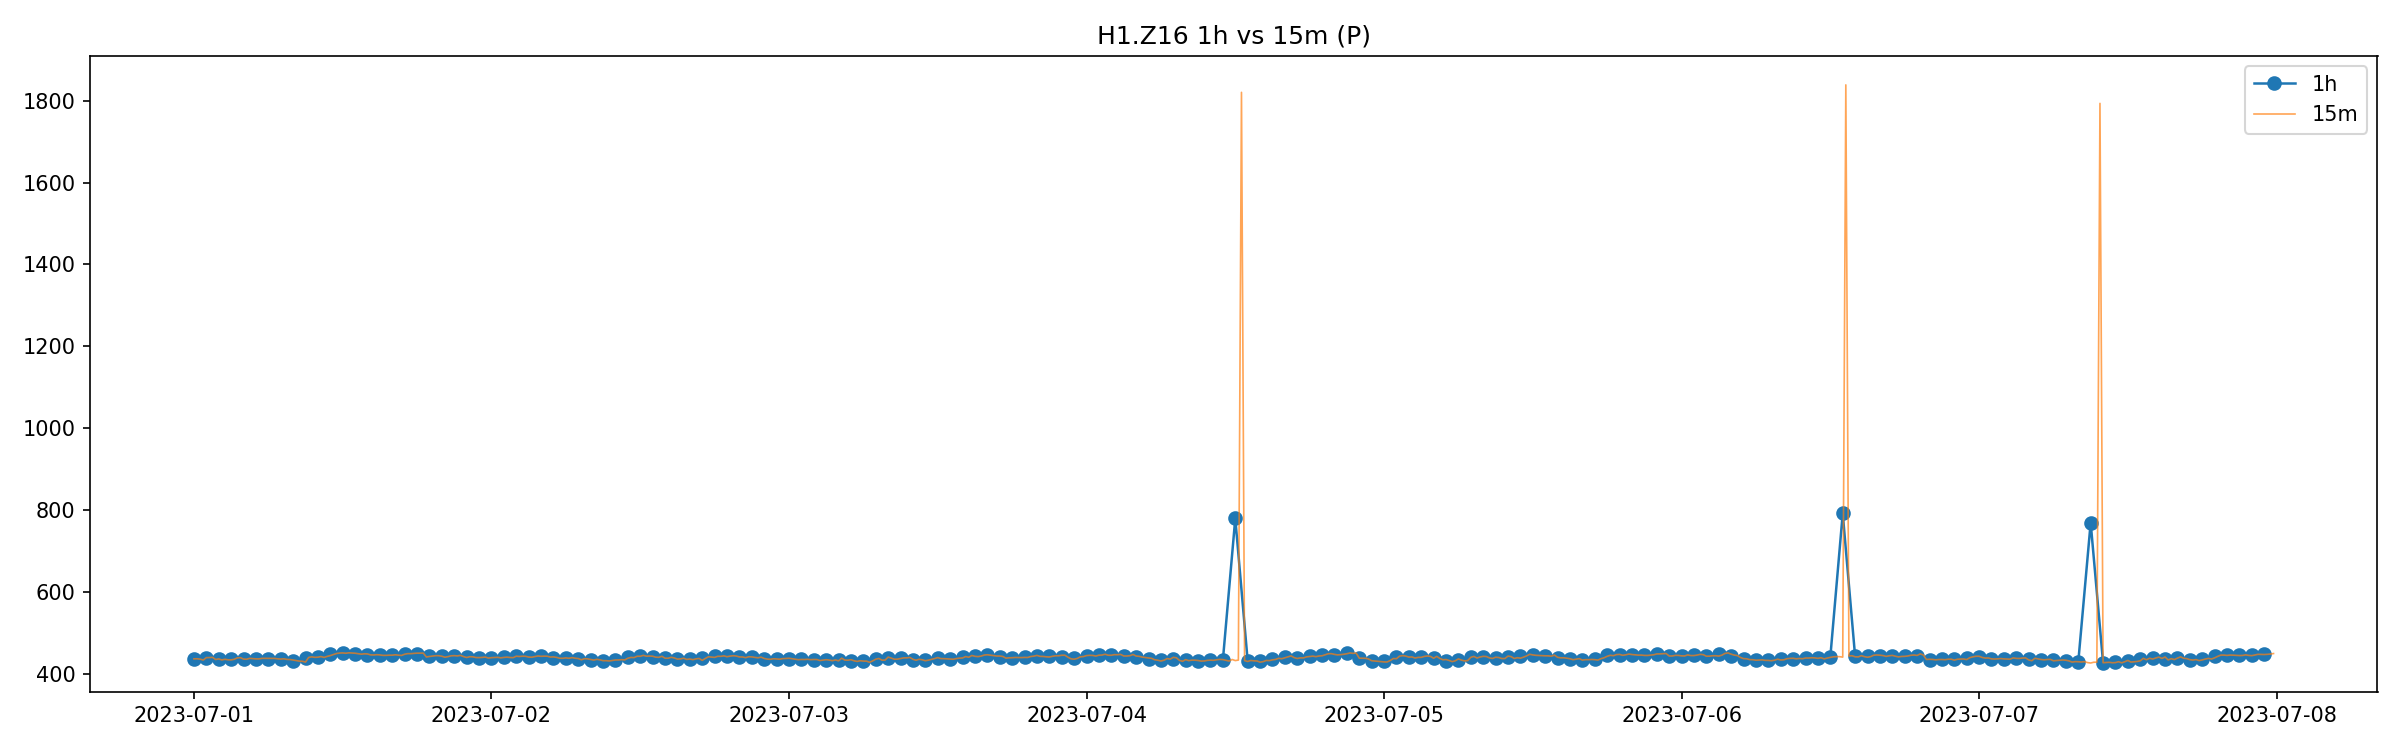

In [3]:
plt.figure(figsize=(16, 5))
plt.plot(df_1h['ts'], df_1h['target_value'], marker='o', linewidth=1.2, label='1h')
plt.plot(df_15m['ts'], df_15m['target_value'], linewidth=0.8, alpha=0.7, label='15m')
plt.title(f'{METER_URN} 1h vs 15m ({target_col})')
plt.legend()
plt.tight_layout()
plot_path = OUTPUT_DIR / f'{METER_URN.replace('.', '_')}_1h_vs_15m.png'
plt.savefig(plot_path, dpi=150)
plt.close()
from IPython.display import Image, display
display(Image(filename=str(plot_path)))


## 3. 데이터 품질 분석과 해상도 비교

In [4]:
compare_df = pd.DataFrame({
    'dataset': ['1h', '15m'],
    'rows': [len(df_1h), len(df_15m)],
    'null_ratio': [df_1h['target_value'].isna().mean(), df_15m['target_value'].isna().mean()],
    'mean': [df_1h['target_value'].mean(), df_15m['target_value'].mean()],
    'std': [df_1h['target_value'].std(), df_15m['target_value'].std()],
    'min': [df_1h['target_value'].min(), df_15m['target_value'].min()],
    'max': [df_1h['target_value'].max(), df_15m['target_value'].max()],
})
display(compare_df)
compare_df.to_csv(OUTPUT_DIR / f'{METER_URN.replace(".", "_")}_compare_stats.csv', index=False, encoding='utf-8-sig')
print('saved:', OUTPUT_DIR / f'{METER_URN.replace(".", "_")}_compare_stats.csv')
print('saved:', OUTPUT_DIR / f'{METER_URN.replace(".", "_")}_1h_vs_15m.png')

,dataset,rows,null_ratio,mean,std,min,max
0,1h,168,0.0,445.883498,45.543468,427.977288,792.044029
1,15m,672,0.0,445.883498,92.064825,426.878261,1838.380667


saved: /home/playdata2/final_pj/energy-platform/outputs/eda/compare_1h_15m/H1_Z16_compare_stats.csv
saved: /home/playdata2/final_pj/energy-platform/outputs/eda/compare_1h_15m/H1_Z16_1h_vs_15m.png
